## Fake News Classifier

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from spacy import displacy
from spacy import tokenizer

from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [8]:
# Set plot params
plt.rcParams["figure.figsize"] = (8, 4)
default_plot_colour = "#bf1300"

### Load Data

In [4]:
data = pd.read_csv("../data/fake_news_data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


In [5]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [6]:
data.tail()

,title,text,date,fake_or_factual
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News
197,UNBELIEVABLE! Students Succeed In Removing US ...,This is not some small obscure community colle...,"Oct 28, 2015",Fake News


### Data Exploration

#### Dataset Balance

Text(0.5, 1.0, 'Count of Article Classification')

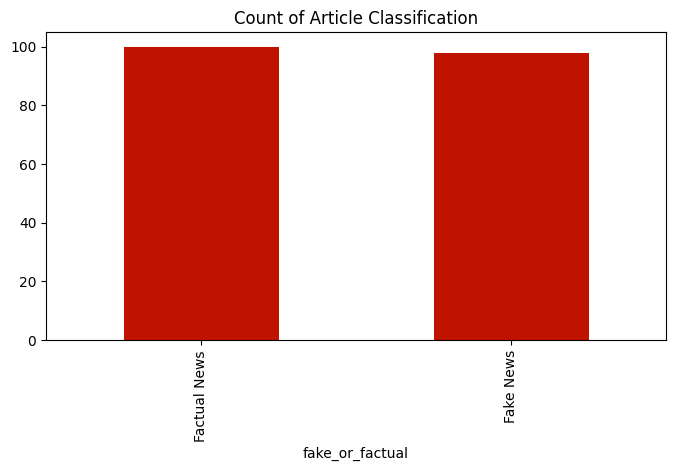

In [ ]:
# Check dataset balance
data.fake_or_factual.value_counts().plot(kind="bar", color=default_plot_colour)
plt.title("Count of Article Classification")

#### Parts of Speech (PoS) Tagging

In [10]:
nlp = spacy.load("en_core_web_sm")

In [64]:
# Split the data into fake/factual
fake_news = data[data["fake_or_factual"] == "Fake News"]
fact_news = data[data["fake_or_factual"] == "Factual News"]

In [65]:
# Create spacy documents
fake_spacy_docs = list(nlp.pipe(fake_news["text"]))
fact_spacy_docs = list(nlp.pipe(fact_news["text"]))

In [66]:
# Function to extract tags
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [67]:
fake_tags_df = []
fact_tags_df = []
columns = ["token", "ner_tag", "pos_tag"]

In [68]:
# Get tags for fake news docs
for ix, doc in enumerate(fake_spacy_docs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tags_df.append(tags)
    
fake_tags_df = pd.concat(fake_tags_df)

In [69]:
fake_tags_df.head()

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [70]:
# Get tags for factual news docs
for ix, doc in enumerate(fact_spacy_docs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tags_df.append(tags)
    
fact_tags_df = pd.concat(fact_tags_df)

In [71]:
fact_tags_df.head()

,token,ner_tag,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT


In [72]:
# Check the most common pos tags
fake_pos_counts = fake_tags_df.groupby(["token", "pos_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
fake_pos_counts.head(10)

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [73]:
# Check the most common pos tags
fact_pos_counts = fact_tags_df.groupby(["token", "pos_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
fact_pos_counts.head(10)

,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [74]:
# Check the most common noun tags
fake_pos_counts.groupby("pos_tag")["token"].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
Name: token, dtype: int64

In [75]:
# Check the most common noun tags
fact_pos_counts.groupby("pos_tag")["token"].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
Name: token, dtype: int64

In [76]:
fake_pos_counts[fake_pos_counts.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [77]:
fact_pos_counts[fact_pos_counts.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
4259,law,NOUN,42


In [78]:
# Check the most common verb tags
fake_pos_counts[fake_pos_counts.pos_tag == "VERB"][:15]

,token,pos_tag,counts
6763,s,VERB,147
6774,said,VERB,144
4703,have,VERB,76
5171,know,VERB,54
7534,told,VERB,49
5394,made,VERB,45
4645,had,VERB,43
4565,going,VERB,40
4562,go,VERB,40
6797,say,VERB,34


In [79]:
fact_pos_counts[fact_pos_counts.pos_tag == "VERB"][:15]

,token,pos_tag,counts
5567,said,VERB,451
6210,told,VERB,55
3841,have,VERB,43
6649,’s,VERB,35
4021,including,VERB,33
4410,make,VERB,31
4395,made,VERB,29
6072,take,VERB,28
3168,do,VERB,25
5582,saying,VERB,24


#### Extract Named Entities

In [80]:
fake_top_entities = fake_tags_df[fake_tags_df["ner_tag"] != ""].groupby(["token", "ner_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)

In [81]:
fact_top_entities = fact_tags_df[fact_tags_df["ner_tag"] != ""].groupby(["token", "ner_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)

In [82]:
# create custom palette to ensure plots are consistent
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

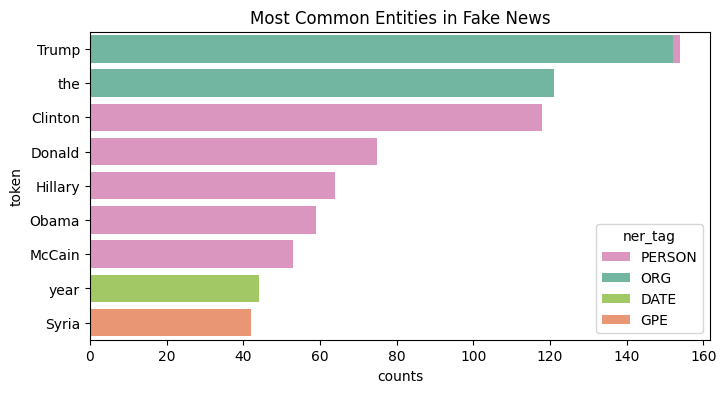

In [84]:
sns.barplot(
    x = "counts",
    y = "token",
    hue = "ner_tag",
    palette = ner_palette,
    data = fake_top_entities[0:10],
    orient = "h",
    dodge=False
).set(title="Most Common Entities in Fake News")

[Text(0.5, 1.0, 'Most Common Entities in Factual News')]

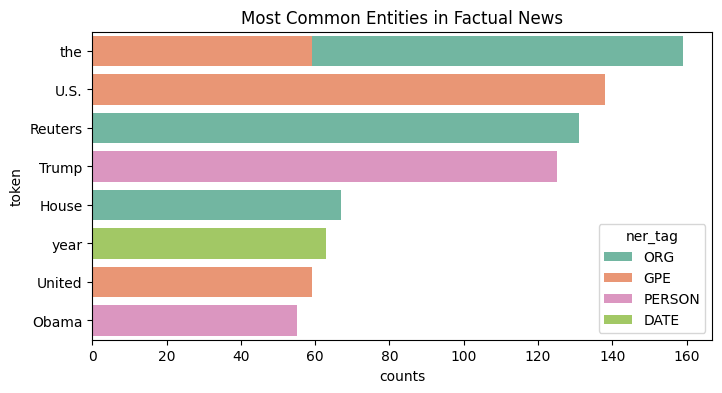

In [85]:
sns.barplot(
    x = "counts",
    y = "token",
    hue = "ner_tag",
    palette = ner_palette,
    data = fact_top_entities[0:10],
    orient = "h",
    dodge=False
).set(title="Most Common Entities in Factual News")

### Text Preprocessing